# Day 3 — Dimensionality Reduction with PCA

After learning how to group data using clustering methods, the next step is to understand what happens when a dataset has many features. Working with a large number of features can make data harder to understand, visualize, and sometimes even harder for machine learning models to use effectively.

In this part, I will learn about Dimensionality Reduction and focus mainly on PCA (Principal Component Analysis). The main idea is to reduce the number of features while keeping as much important information from the original data as possible.

# The Curse of Dimensionality

When a dataset has many features, it becomes more difficult to work with.

# For example, imagine a dataset about customers containing:

    - Age
    - Income
    - Spending score
    - Number of purchases
    - Website visits
    - Average order value
    - Time spent on the website
    = Number of previous orders
    - and many more features

# Having many features can cause several problems:

    - The data becomes more sparse.
    - Distances between points become less meaningful.
    - Models can become more likely to overfit.
    - Visualizing the data becomes difficult because we cannot easily visualize dozens or hundreds of dimensions.

Dimensionality Reduction tries to solve this by reducing many features into a smaller number of dimensions while keeping as much useful information as possible.

In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Imagine that each row represents one customer
# and each column represents a different customer feature.
X = np.array([
    [22, 2500, 30, 4, 12],
    [25, 2800, 35, 5, 15],
    [45, 6000, 80, 15, 40],
    [48, 6500, 85, 16, 42],
    [30, 3200, 45, 7, 18]
])

print("Original number of features:", X.shape[1])

# Before dimensionality reduction, we usually scale the data
# because the features may have different ranges.
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data:")
print(X_scaled)

Original number of features: 5
Scaled data:
[[-1.13592367 -1.00243098 -1.08593061 -1.06230079 -1.03929068]
 [-0.85194275 -0.8255314  -0.86874449 -0.86557842 -0.80661366]
 [ 1.04126336  1.06139751  1.08593061  1.10164527  1.13236149]
 [ 1.32524428  1.35623015  1.30311673  1.29836763  1.2874795 ]
 [-0.37864122 -0.58966528 -0.43437224 -0.47213369 -0.57393664]]


# What I should understand from this example ?

The important idea is that the original dataset has 5 dimensions/features.

If the dataset had 50 or 100 features, it would become harder to visualize and work with.

PCA can help transform these original features into a smaller number of new components while preserving a large amount of the information contained in the original dataset.

# What PCA Does ?

PCA (Principal Component Analysis) is a dimensionality reduction technique.

Instead of simply deleting some original columns, PCA creates new components.

These components are new directions in the data that capture the greatest amount of variance.

The first component captures the most variance possible.

The second component captures the next largest amount of variance while being independent in direction from the first, and so on.

A simple way to think about it:

PCA tries to find the most informative directions in the data and represent the original dataset using those directions.

# Practical Example

In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = np.array([
    [22, 2500, 30, 4, 12],
    [25, 2800, 35, 5, 15],
    [45, 6000, 80, 15, 40],
    [48, 6500, 85, 16, 42],
    [30, 3200, 45, 7, 18]
])

# Step 1: Scale the features.
# PCA is affected by feature scale, so we should standardize first.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Ask PCA to reduce the 5 original features
# into only 2 principal components.
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)

print("Reduced data:")
print(X_pca)

Original shape: (5, 5)
Reduced shape: (5, 2)
Reduced data:
[[-2.38179921 -0.09665692]
 [-1.88655052 -0.04095337]
 [ 2.42508657 -0.03547057]
 [ 2.93836512 -0.00791319]
 [-1.09510196  0.18099406]]


# What happened here?

Before PCA:
    5 features

After PCA:
    2 components

So instead of working with 5 dimensions, I now have 2 dimensions.

The important thing is that these two components are not simply two original columns. They are combinations of the original features that represent important directions of variation in the data.

# Why Scaling Is Important Before PCA?

PCA is based on variance.

If one feature has much larger numerical values than another, it can have a much stronger effect on the PCA result.

For example:

Age              → 18 to 60
Income           → 2000 to 10000
Number of visits → 1 to 20

Income has a much larger numerical scale than the other features.

If I apply PCA directly without scaling, PCA may give too much importance to features simply because their values are numerically larger.

Therefore, I should usually apply StandardScaler before PCA.

# Practical Example

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Original dataset with features that have very different scales.
X = [
    [20, 2000],
    [25, 3000],
    [30, 5000],
    [40, 8000],
    [50, 12000]
]

# StandardScaler changes the features to a comparable scale.
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Now PCA works on the scaled features rather than
# allowing the larger-range feature to dominate.
pca = PCA(n_components=1)

X_reduced = pca.fit_transform(X_scaled)

print(X_reduced)

[[-1.63199076]
 [-1.10909994]
 [-0.39158439]
 [ 0.84882199]
 [ 2.2838531 ]]


# The main lesson is:

Scale first, then apply PCA.

# Explained Variance

One of the most important concepts in PCA is Explained Variance Ratio.

It tells me how much of the original information/variance is captured by each principal component.

For example, PCA might produce:

Component 1 → 70%
Component 2 → 20%
Component 3 → 7%
Component 4 → 3%

This means:

The first component contains 70% of the variance.
The first two components together contain 90%.
The first three components contain 97%.

So if I only keep the first two components, I preserve about 90% of the variance while reducing the number of dimensions.

In [4]:
# Practical Example

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Example dataset
X = [
    [10, 100, 5, 50],
    [12, 120, 6, 55],
    [20, 200, 10, 90],
    [22, 210, 11, 95],
    [30, 300, 15, 130],
    [32, 320, 16, 140]
]

# Scale the data before PCA.
X_scaled = StandardScaler().fit_transform(X)

# Keep all components for now.
# This allows me to see how much variance each component explains.
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Variance explained by each component:")
print(pca.explained_variance_ratio_)

# Add the variance of the components together
# to see how much information is retained cumulatively.
print("Cumulative explained variance:")
print(pca.explained_variance_ratio_.cumsum())

Variance explained by each component:
[9.99413462e-01 4.39960274e-04 1.46577412e-04 6.26987961e-33]
Cumulative explained variance:
[0.99941346 0.99985342 1.         1.        ]


# What I should look for

The cumulative values help me decide how many components I should keep.

For example, if I get:

[0.60, 0.25, 0.10, 0.05]

The cumulative variance is:

Component 1 → 60%
Component 2 → 85%
Component 3 → 95%
Component 4 → 100%

If my goal is to keep around 95% of the variance, I would keep the first 3 components. A common rule is to retain approximately 95% of the variance, although the exact choice depends on the problem.

# Choosing the Number of Components

I should not always choose n_components=2.

Using two components is useful when I want to create a 2D visualization, but for actual dimensionality reduction I need to decide how many components provide enough information.

A common approach is:

Scale the data.
Run PCA with all components.
Calculate the explained variance.
Look at the cumulative explained variance.
Choose enough components to preserve around 95% of the variance.

[0.9992964  0.99994193 1.         1.         1.        ]


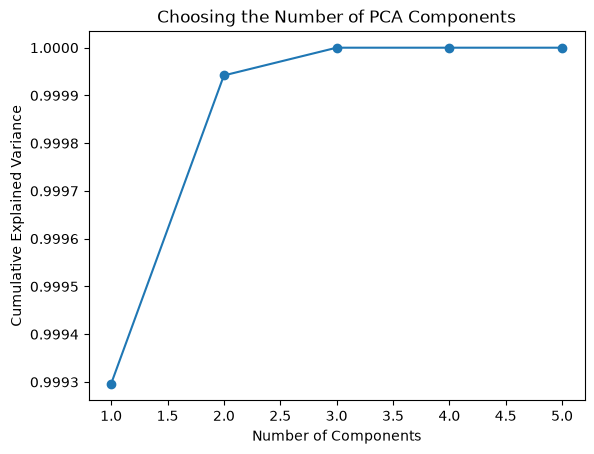

In [5]:
# Practical Example: Choosing the Number of Components
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Create example data with several features.
X = np.array([
    [10, 20, 30, 40, 50],
    [12, 22, 31, 42, 51],
    [20, 35, 45, 60, 70],
    [22, 37, 47, 62, 72],
    [30, 50, 60, 80, 90],
    [32, 52, 62, 82, 92]
])

# Scale the features so that PCA does not favor
# a feature just because it has a larger numerical range.
X_scaled = StandardScaler().fit_transform(X)

# Fit PCA without deciding the number of components yet.
pca = PCA()

pca.fit(X_scaled)

# Calculate how much variance is retained
# as we keep more components.
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

# Plot the cumulative explained variance.
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Choosing the Number of PCA Components")

plt.show()

# What the graph tells me

The graph helps me answer:

How many components do I need before I preserve enough information?

If the curve reaches approximately 0.95 at component 3, then 3 components may be enough for my purpose.

This is better than choosing a number randomly because I am using the actual variance in the dataset to make the decision.

# Reducing the Data to 2D for Visualization

Another important use of PCA is making high-dimensional data easier to visualize.

Humans can easily understand a 2D plot, but we cannot directly visualize a dataset with 10 or 50 features.

PCA can reduce the dataset to two components:

Many features
      ↓
     PCA
      ↓
PC1 + PC2
      ↓
   2D plot

This allows me to visually inspect whether there are groups or patterns in the data.

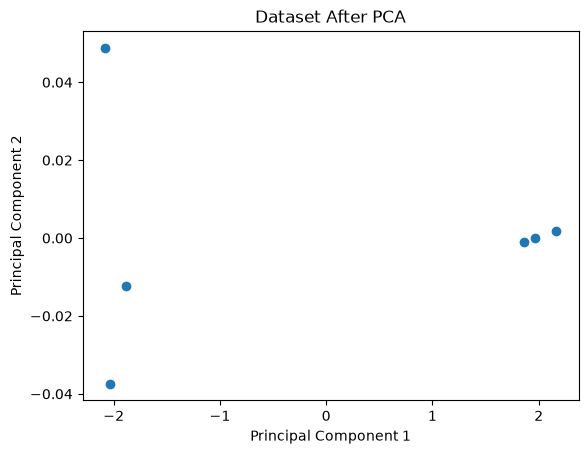

In [6]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Example dataset.
X = [
    [10, 20, 30, 40],
    [12, 21, 32, 41],
    [11, 19, 29, 39],
    [50, 60, 70, 80],
    [52, 62, 72, 82],
    [49, 59, 69, 79]
]

# Scale the original features before PCA.
X_scaled = StandardScaler().fit_transform(X)

# Reduce the dataset from 4 dimensions to 2.
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# The first column represents PC1.
# The second column represents PC2.
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Dataset After PCA")

plt.show()

# What I should understand

The x-axis is now Principal Component 1 and the y-axis is Principal Component 2.

These are not original features such as "Age" or "Income".

They are new combinations of the original features created by PCA.

If the points form visible groups in the plot, this can help me understand the structure of the dataset.

# When Should I Use PCA?

PCA has several useful applications.

1. Reducing the Number of Features

If I have many features, PCA can reduce them into fewer components.

This can make the dataset easier to work with.

2. Reducing Redundant Information

If several features contain similar or correlated information, PCA can represent that information using fewer components.

3. Visualization

PCA can reduce high-dimensional data to 2D or 3D so I can visualize it.

# What Is the Trade-off?

PCA is useful, but it also has a disadvantage.

The original features are easy to understand:

Age
Income
Purchases
Visits

After PCA, I might have:

Principal Component 1
Principal Component 2

Each component is a combination of the original features, so it becomes harder to directly explain what a component means.

For example, I cannot simply say:

"PC1 means income."

Instead, PC1 might be influenced by income, purchases, and visits together.

So PCA gives me a simpler representation of the data, but I may lose some of the direct interpretability of the original features.

# Complete PCA Workflow

The workflow I should remember is:

Original Dataset
       ↓

Check the features
       ↓

Scale the data
       ↓

Apply PCA
       ↓

Check explained variance
       ↓

Choose number of components
       ↓

Transform the data
       ↓
       
Use reduced data for modeling or visualization

In [7]:
# Practical Example

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------------------------------------
# 1. Start with the original data
# ---------------------------------------

X = [
    [10, 100, 5, 20],
    [12, 110, 6, 22],
    [20, 200, 10, 40],
    [22, 210, 11, 42],
    [30, 300, 15, 60],
    [32, 320, 16, 65]
]


# ---------------------------------------
# 2. Scale the features
# ---------------------------------------

# PCA is sensitive to feature scale,
# so we standardize before applying PCA.
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ---------------------------------------
# 3. Check the explained variance
# ---------------------------------------

# First, keep all components so I can
# understand how much variance each one captures.
pca = PCA()

X_all_components = pca.fit_transform(X_scaled)

print("Explained variance:")
print(pca.explained_variance_ratio_)

print("Cumulative variance:")
print(pca.explained_variance_ratio_.cumsum())


# ---------------------------------------
# 4. Choose the number of components
# ---------------------------------------

# Suppose I decide that 2 components
# are enough for my visualization.
pca_2d = PCA(n_components=2)

X_reduced = pca_2d.fit_transform(X_scaled)


# ---------------------------------------
# 5. Use the reduced dataset
# ---------------------------------------

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_reduced.shape)

Explained variance:
[9.99223309e-01 7.41418966e-04 3.52720620e-05 7.30305375e-33]
Cumulative variance:
[0.99922331 0.99996473 1.         1.        ]
Original shape: (6, 4)
Reduced shape: (6, 2)
